# Emotion Detection with VGG16 in PyTorch

**Architecture:** VGG16 built from scratch, without pretrained weights.  
**Dataset:** `./dataset` with `train`, `validation`, and `test` folders.

---
## 1. Import Libraries

In [1]:
import json
import os
import random
from collections import defaultdict

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:   {torch.cuda.is_available()}')
print(f'MPS available:    {torch.backends.mps.is_available()}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device:           {DEVICE}')

PyTorch version: 2.12.0
CUDA available:   False
MPS available:    True
Device:           mps


---
## 2. Dataset Configuration & Loading

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

DATASET_ROOT = '../dataset'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VALIDATION_DIR = os.path.join(DATASET_ROOT, 'validation')
TEST_DIR = os.path.join(DATASET_ROOT, 'test')

IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
NUM_CLASSES = 8
NUM_WORKERS = 0

EMOTIONS = sorted(os.listdir(TRAIN_DIR))
print(f'Detected {len(EMOTIONS)} emotion classes: {EMOTIONS}')

for split_name, path in [('Train', TRAIN_DIR), ('Validation', VALIDATION_DIR), ('Test', TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(path, emotion))) for emotion in EMOTIONS)
    print(f'{split_name:12s}: {total:,} images  ({total // len(EMOTIONS)} per class)')

Detected 8 emotion classes: ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
Train       : 16,000 images  (2000 per class)
Validation  : 3,200 images  (400 per class)
Test        : 3,200 images  (400 per class)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASETS AND DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        shear=0.1,
        scale=(0.9, 1.1),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
validation_dataset = datasets.ImageFolder(VALIDATION_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

class_to_idx = train_dataset.class_to_idx
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in range(NUM_CLASSES)]

pin_memory = DEVICE.type == 'cuda'
loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_kwargs,
)
validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

print('\nClass → Index mapping:')
for name, idx in class_to_idx.items():
    print(f'  {idx}: {name}')

print(f'\nTrain samples:      {len(train_dataset):,}')
print(f'Validation samples: {len(validation_dataset):,}')
print(f'Test samples:       {len(test_dataset):,}')


Class → Index mapping:
  0: Anger
  1: Contempt
  2: Disgust
  3: Fear
  4: Happiness
  5: Neutral
  6: Sadness
  7: Surprise

Train samples:      16,000
Validation samples: 3,200
Test samples:       3,200


---
## 3. Data Visualization

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

required_names = {'checkpoint_path', 'model', 'predict_loader', 'test_loader'}
if required_names.issubset(globals()):
    if os.path.exists(checkpoint_path):
        best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(best_checkpoint['model_state_dict'])
        print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

    print('Generating predictions on test set ...')
    y_prob, y_true, y_pred = predict_loader(test_loader)

    print(f'\nTrue labels shape : {y_true.shape}')
    print(f'Pred labels shape : {y_pred.shape}')
else:
    print('Skipping test-set prediction preview until the model and training utilities are defined.')

Skipping test-set prediction preview until the model and training utilities are defined.


---
## 4. Build VGG16 from Scratch

**VGG (Very Deep Convolutional Networks)** uses very small (3×3) convolution filters in an architecture that increases in depth, demonstrating that depth is a critical component for achieving strong classification performance.

For each convolutional layer, the operation is: $f(x) = \text{ReLU}(W * x + b)$

This results in a hierarchy of increasingly abstract feature representations, with max-pooling layers halving spatial dimensions between groups.

**VGG16 configuration:**
| Block | Layers |
|-------|--------|
| Block 1 | Conv3-64, Conv3-64, MaxPool |
| Block 2 | Conv3-128, Conv3-128, MaxPool |
| Block 3 | Conv3-256, Conv3-256, Conv3-256, MaxPool |
| Block 4 | Conv3-512, Conv3-512, Conv3-512, MaxPool |
| Block 5 | Conv3-512, Conv3-512, Conv3-512, MaxPool |

Adapted for **48×48 input** (smaller than ImageNet 224×224 — only 3 pooling layers used to preserve spatial information).

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# VGG16 BUILT FROM SCRATCH IN PYTORCH
# ─────────────────────────────────────────────────────────────────────────────

class VGGBlock(nn.Module):
    """A VGG convolutional block: one or more Conv2d → BatchNorm → ReLU layers followed by MaxPool."""

    def __init__(self, in_channels, out_channels, num_convs, use_pool=True):
        super().__init__()
        layers = []
        for i in range(num_convs):
            ch_in = in_channels if i == 0 else out_channels
            layers += [
                nn.Conv2d(ch_in, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ]
        if use_pool:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VGG16Scratch(nn.Module):
    """
    VGG16 built from scratch in PyTorch, adapted for 48×48 grayscale-sourced
    (3-channel) emotion images.

    The standard VGG16 uses 5 MaxPool layers (224→7).  For 48×48 inputs we
    use only 3 pooling layers (48→6) so the spatial map remains large enough
    for the classifier head.

    Architecture:
        Block 1: 2× Conv3-64                    48×48 → 48×48  (+pool → 24×24)
        Block 2: 2× Conv3-128                   24×24 → 24×24  (+pool → 12×12)
        Block 3: 3× Conv3-256                   12×12 → 12×12  (+pool →  6×6)
        Block 4: 3× Conv3-512                    6×6  →  6×6   (no pool)
        Block 5: 3× Conv3-512                    6×6  →  6×6   (no pool)
        AdaptiveAvgPool → 1×1
        Classifier: 512 → 256 → num_classes
    """

    def __init__(
        self,
        input_channels=3,
        num_classes=8,
        dropout_rate=0.5,
    ):
        super().__init__()

        # ── Feature extractor ──────────────────────────────────────────────
        self.block1 = VGGBlock(input_channels,  64, num_convs=2, use_pool=True)
        self.block2 = VGGBlock(64,             128, num_convs=2, use_pool=True)
        self.block3 = VGGBlock(128,            256, num_convs=3, use_pool=True)
        self.block4 = VGGBlock(256,            512, num_convs=3, use_pool=False)  # no pool: 6×6 preserved
        self.block5 = VGGBlock(512,            512, num_convs=3, use_pool=False)  # no pool: 6×6 preserved

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # → 512 × 1 × 1

        # ── Classifier ─────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1.0)
            nn.init.constant_(module.bias, 0.0)
        elif isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, 0.0, 0.01)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_vgg16(
    input_channels=3,
    num_classes=8,
    dropout_rate=0.5,
):
    return VGG16Scratch(
        input_channels=input_channels,
        num_classes=num_classes,
        dropout_rate=dropout_rate,
    )


model = build_vgg16(
    input_channels=3,
    num_classes=NUM_CLASSES,
    dropout_rate=0.5,
).to(DEVICE)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'\nTrainable parameters: {num_parameters:,}')

VGG16Scratch(
  (block1): VGGBlock(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block2): VGGBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, mo

---
## 5. Compile & Train the Model

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTIMISATION, SCHEDULING, AND HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
checkpoint_path = 'best_vgg16_emotion.pt'


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=pin_memory)
        labels = labels.to(DEVICE, non_blocking=pin_memory)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        predictions = outputs.argmax(dim=1)
        running_correct += (predictions == labels).sum().item()
        running_total += batch_size

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    return avg_loss, avg_acc


def predict_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    all_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=pin_memory)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_true.append(labels.numpy())
            all_pred.append(preds.cpu().numpy())

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)
    return y_prob, y_true, y_pred


print('Training utilities ready.')

Training utilities ready.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN
# ─────────────────────────────────────────────────────────────────────────────

history = defaultdict(list)
best_val_acc = 0.0
best_val_loss = float('inf')
best_val_acc_epoch = 0
best_val_loss_epoch = 0
patience = 10
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(validation_loader, training=False)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_acc_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'class_to_idx': class_to_idx,
                'img_size': IMG_SIZE,
                'num_classes': NUM_CLASSES,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_loss_epoch = epoch

    print(
        f'Epoch {epoch:02d}/{EPOCHS:02d} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.2e}'
    )

    if epochs_without_improvement >= patience:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f'\nLoaded best model from epoch {best_checkpoint["epoch"]} with val accuracy {best_checkpoint["best_val_acc"]:.4f}.')

print('\n✅ Training complete!')

Epoch 01/50 | train_loss=1.7423 train_acc=0.3070 | val_loss=2.1098 val_acc=0.2884 | lr=1.00e-03
Epoch 02/50 | train_loss=1.1908 train_acc=0.5217 | val_loss=0.8562 val_acc=0.6134 | lr=1.00e-03
Epoch 03/50 | train_loss=0.7152 train_acc=0.7258 | val_loss=1.1333 val_acc=0.6734 | lr=1.00e-03
Epoch 04/50 | train_loss=0.4443 train_acc=0.8529 | val_loss=1.7887 val_acc=0.6009 | lr=1.00e-03
Epoch 05/50 | train_loss=0.3148 train_acc=0.9053 | val_loss=0.7051 val_acc=0.8159 | lr=1.00e-03
Epoch 06/50 | train_loss=0.2375 train_acc=0.9301 | val_loss=0.3802 val_acc=0.8878 | lr=1.00e-03
Epoch 07/50 | train_loss=0.2000 train_acc=0.9427 | val_loss=0.9450 val_acc=0.8159 | lr=1.00e-03
Epoch 08/50 | train_loss=0.1586 train_acc=0.9529 | val_loss=1.2904 val_acc=0.7762 | lr=1.00e-03
Epoch 09/50 | train_loss=0.1575 train_acc=0.9559 | val_loss=0.8150 val_acc=0.8169 | lr=1.00e-03
Epoch 10/50 | train_loss=0.1271 train_acc=0.9625 | val_loss=0.8147 val_acc=0.7897 | lr=1.00e-03
Epoch 11/50 | train_loss=0.1238 train_ac

---
## 6. Training vs Validation — Accuracy & Loss Curves

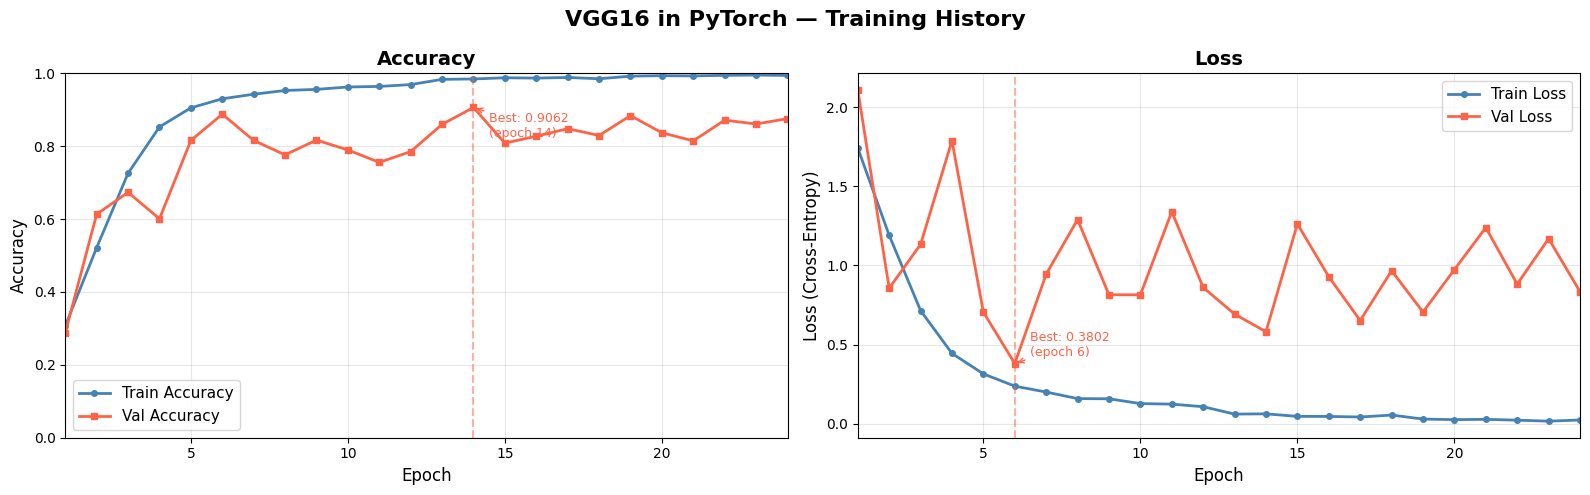

Plot saved as training_curves.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING vs VALIDATION — ACCURACY & LOSS CURVES
# ─────────────────────────────────────────────────────────────────────────────

epochs_ran = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('VGG16 in PyTorch — Training History', fontsize=16, fontweight='bold')

ax = axes[0]
ax.plot(epochs_ran, history['train_acc'], color='steelblue', linewidth=2, marker='o', markersize=4, label='Train Accuracy')
ax.plot(epochs_ran, history['val_acc'], color='tomato', linewidth=2, marker='s', markersize=4, label='Val Accuracy')
ax.set_title('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs_ran))
ax.set_ylim(0, 1)
ax.axvline(x=best_val_acc_epoch, color='tomato', linestyle='--', alpha=0.5)
ax.annotate(
    f'Best: {best_val_acc:.4f}\n(epoch {best_val_acc_epoch})',
    xy=(best_val_acc_epoch, best_val_acc),
    xytext=(best_val_acc_epoch + 0.5, max(0.05, best_val_acc - 0.08)),
    fontsize=9,
    color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato'),
)

ax = axes[1]
ax.plot(epochs_ran, history['train_loss'], color='steelblue', linewidth=2, marker='o', markersize=4, label='Train Loss')
ax.plot(epochs_ran, history['val_loss'], color='tomato', linewidth=2, marker='s', markersize=4, label='Val Loss')
ax.set_title('Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs_ran))
ax.axvline(x=best_val_loss_epoch, color='tomato', linestyle='--', alpha=0.5)
ax.annotate(
    f'Best: {best_val_loss:.4f}\n(epoch {best_val_loss_epoch})',
    xy=(best_val_loss_epoch, best_val_loss),
    xytext=(best_val_loss_epoch + 0.5, best_val_loss + 0.05),
    fontsize=9,
    color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato'),
)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_curves.png')

---
## 7. Performance Metrics

Evaluate on the **held-out test set** (never seen during training or validation).

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

if 'predict_loader' not in globals():
    raise RuntimeError('Run the training utilities cell before this evaluation cell.')

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

print('Generating predictions on test set ...')
y_prob, y_true, y_pred = predict_loader(test_loader)

# Map indices back to class names
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'\nTrue labels shape : {y_true.shape}')
print(f'Pred labels shape : {y_pred.shape}')

Loaded best checkpoint from epoch 14.
Generating predictions on test set ...

True labels shape : (3200,)
Pred labels shape : (3200,)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# OVERALL METRICS
# ─────────────────────────────────────────────────────────────────────────────

acc = accuracy_score(y_true, y_pred)
prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
prec_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec_m = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 60)
print('           OVERALL PERFORMANCE METRICS (Test Set)')
print('=' * 60)
print(f'  Accuracy                        : {acc:.4f}  ({acc * 100:.2f}%)')
print()
print(f'  Weighted Precision               : {prec_w:.4f}')
print(f'  Weighted Recall                  : {rec_w:.4f}')
print(f'  Weighted F1-Score                : {f1_w:.4f}')
print()
print(f'  Macro Precision                  : {prec_m:.4f}')
print(f'  Macro Recall                     : {rec_m:.4f}')
print(f'  Macro F1-Score                   : {f1_m:.4f}')
print('=' * 60)

           OVERALL PERFORMANCE METRICS (Test Set)
  Accuracy                        : 0.9325  (93.25%)

  Weighted Precision               : 0.9370
  Weighted Recall                  : 0.9325
  Weighted F1-Score                : 0.9306

  Macro Precision                  : 0.9370
  Macro Recall                     : 0.9325
  Macro F1-Score                   : 0.9306


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────────────────

print('\nDetailed Classification Report:')
print('-' * 60)
report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)


Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       Anger     0.9038    0.8925    0.8981       400
    Contempt     0.9153    1.0000    0.9558       400
     Disgust     0.9476    0.9500    0.9488       400
        Fear     0.9825    0.9825    0.9825       400
   Happiness     0.9344    0.9975    0.9649       400
     Neutral     0.8229    0.9525    0.8830       400
     Sadness     0.9894    0.6975    0.8182       400
    Surprise     1.0000    0.9875    0.9937       400

    accuracy                         0.9325      3200
   macro avg     0.9370    0.9325    0.9306      3200
weighted avg     0.9370    0.9325    0.9306      3200



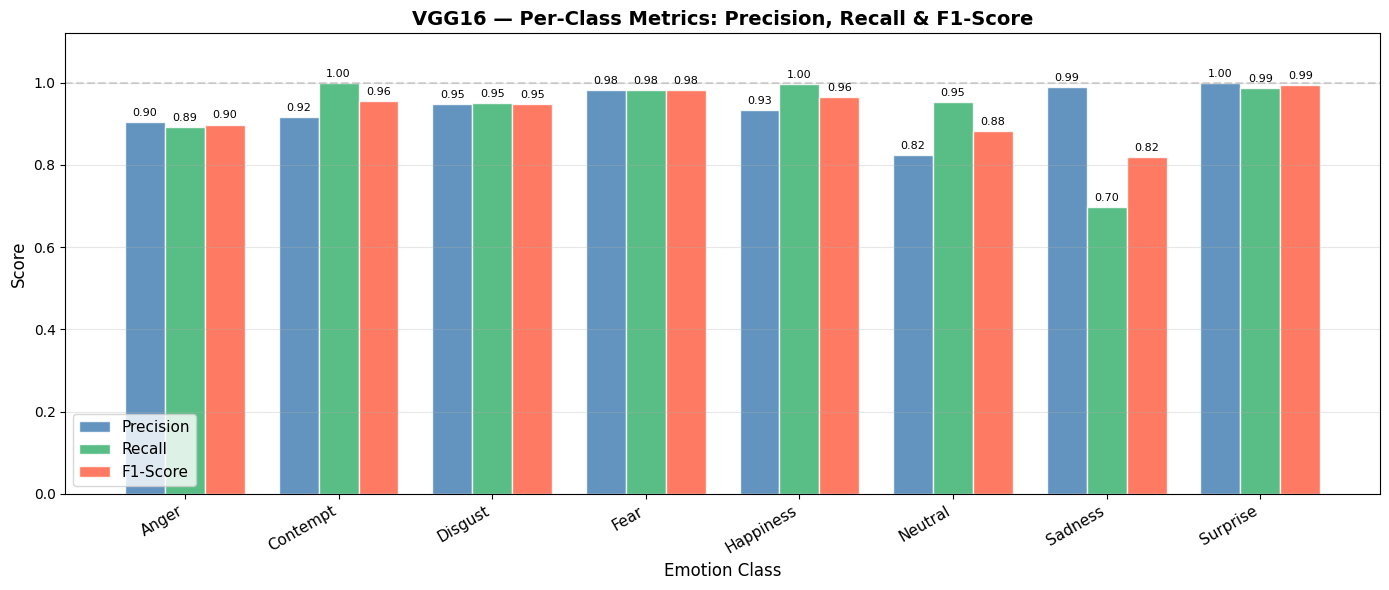

Plot saved as per_class_metrics.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS METRICS — BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

per_class_precision = [report_dict[c]['precision'] for c in class_names]
per_class_recall = [report_dict[c]['recall'] for c in class_names]
per_class_f1 = [report_dict[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, per_class_precision, width, label='Precision', color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x, per_class_recall, width, label='Recall', color='mediumseagreen', alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width, per_class_f1, width, label='F1-Score', color='tomato', alpha=0.85, edgecolor='white')

ax.set_title('VGG16 — Per-Class Metrics: Precision, Recall & F1-Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as per_class_metrics.png')

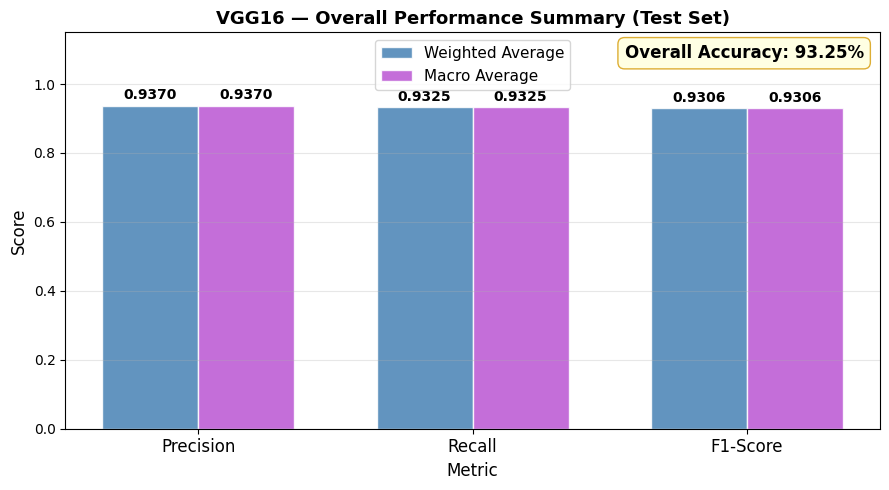

Plot saved as summary_metrics.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY DASHBOARD — Weighted vs Macro comparison
# ─────────────────────────────────────────────────────────────────────────────

metrics_labels = ['Precision', 'Recall', 'F1-Score']
weighted_scores = [prec_w, rec_w, f1_w]
macro_scores = [prec_m, rec_m, f1_m]

x2 = np.arange(len(metrics_labels))
width2 = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x2 - width2 / 2, weighted_scores, width2, label='Weighted Average', color='steelblue', alpha=0.85, edgecolor='white')
b2 = ax.bar(x2 + width2 / 2, macro_scores, width2, label='Macro Average', color='mediumorchid', alpha=0.85, edgecolor='white')

ax.set_title('VGG16 — Overall Performance Summary (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x2)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.annotate(
    f'Overall Accuracy: {acc * 100:.2f}%',
    xy=(0.98, 0.97),
    xycoords='axes fraction',
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='goldenrod', alpha=0.9),
)

plt.tight_layout()
plt.savefig('summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as summary_metrics.png')

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL CONSOLIDATED SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

print('\n' + '=' * 72)
print('                  FINAL PERFORMANCE SUMMARY — TEST SET')
print('=' * 72)
print(f"{'Metric':<40} {'Score':>10}")
print('-' * 52)
print(f"{'Accuracy':<40} {acc:>10.4f}")
print()
print(f"{'Weighted Avg Precision':<40} {prec_w:>10.4f}")
print(f"{'Weighted Avg Recall':<40} {rec_w:>10.4f}")
print(f"{'Weighted Avg F1-Score':<40} {f1_w:>10.4f}")
print()
print(f"{'Macro Avg Precision':<40} {prec_m:>10.4f}")
print(f"{'Macro Avg Recall':<40} {rec_m:>10.4f}")
print(f"{'Macro Avg F1-Score':<40} {f1_m:>10.4f}")
print('-' * 52)
print()
print('Per-Class F1-Scores:')
for cls, f1_value in zip(class_names, per_class_f1):
    bar = '█' * int(f1_value * 30)
    print(f'  {cls:<12} {f1_value:.4f}  {bar}')
print('=' * 72)
best_val_acc_text = f'{best_val_acc:.4f} (Epoch {best_val_acc_epoch})' if 'best_val_acc' in globals() else 'N/A (run training first)'
best_val_loss_text = f'{best_val_loss:.4f} (Epoch {best_val_loss_epoch})' if 'best_val_loss' in globals() else 'N/A (run training first)'
print(f'  Best Validation Accuracy : {best_val_acc_text}')
print(f'  Best Validation Loss     : {best_val_loss_text}')
print('=' * 72)


                  FINAL PERFORMANCE SUMMARY — TEST SET
Metric                                        Score
----------------------------------------------------
Accuracy                                     0.9325

Weighted Avg Precision                       0.9370
Weighted Avg Recall                          0.9325
Weighted Avg F1-Score                        0.9306

Macro Avg Precision                          0.9370
Macro Avg Recall                             0.9325
Macro Avg F1-Score                           0.9306
----------------------------------------------------

Per-Class F1-Scores:
  Anger        0.8981  ██████████████████████████
  Contempt     0.9558  ████████████████████████████
  Disgust      0.9488  ████████████████████████████
  Fear         0.9825  █████████████████████████████
  Happiness    0.9649  ████████████████████████████
  Neutral      0.8830  ██████████████████████████
  Sadness      0.8182  ████████████████████████
  Surprise     0.9937  ██████████████████

---
## 8. Confusion Matrix

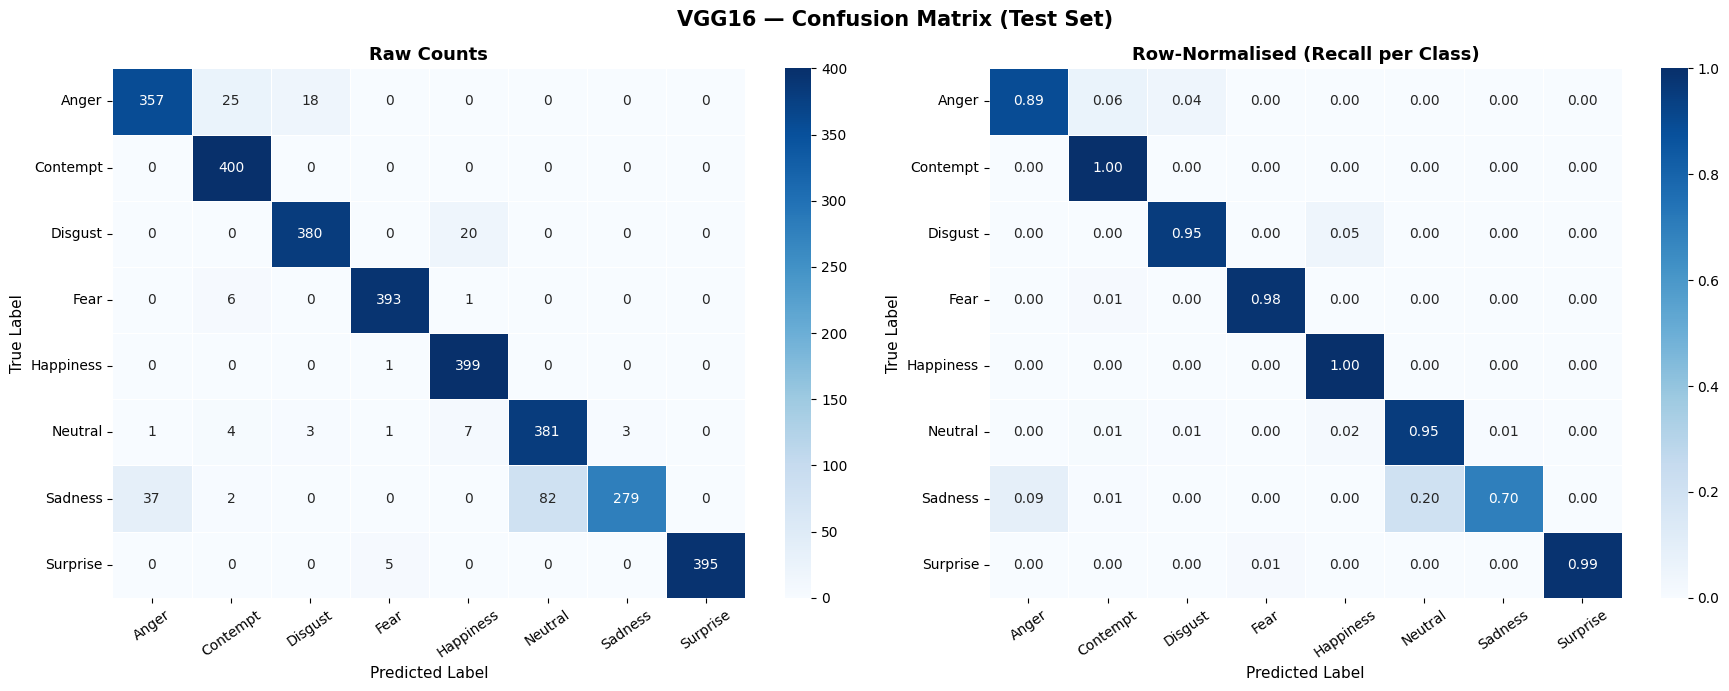

Plot saved as confusion_matrix.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('VGG16 — Confusion Matrix (Test Set)', fontsize=15, fontweight='bold')

# Raw counts
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, ax=axes[0],
)
axes[0].set_title('Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# Row-normalised
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, vmin=0, vmax=1, ax=axes[1],
)
axes[1].set_title('Row-Normalised (Recall per Class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as confusion_matrix.png')

---
## 9. Save Weights & Class Index Map

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE FINAL MODEL WEIGHTS
# ─────────────────────────────────────────────────────────────────────────────

weights_path = 'vgg16_emotion_weights.pt'
torch.save(model.state_dict(), weights_path)
print(f'Model weights saved → {weights_path}')

final_path = 'vgg16_emotion_final.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'img_size': IMG_SIZE,
        'num_classes': NUM_CLASSES,
        'best_val_acc': best_val_acc,
        'best_val_acc_epoch': best_val_acc_epoch,
    },
    final_path,
)
print(f'Full checkpoint saved  → {final_path}')

class_index_path = 'class_indices.json'
with open(class_index_path, 'w') as f:
    json.dump(class_to_idx, f, indent=2)
print(f'Class index map saved  → {class_index_path}')

Model weights saved → vgg16_emotion_weights.pt
Full checkpoint saved  → vgg16_emotion_final.pt
Class index map saved  → class_indices.json


---
## Bonus: Quick Inference on a Single Image

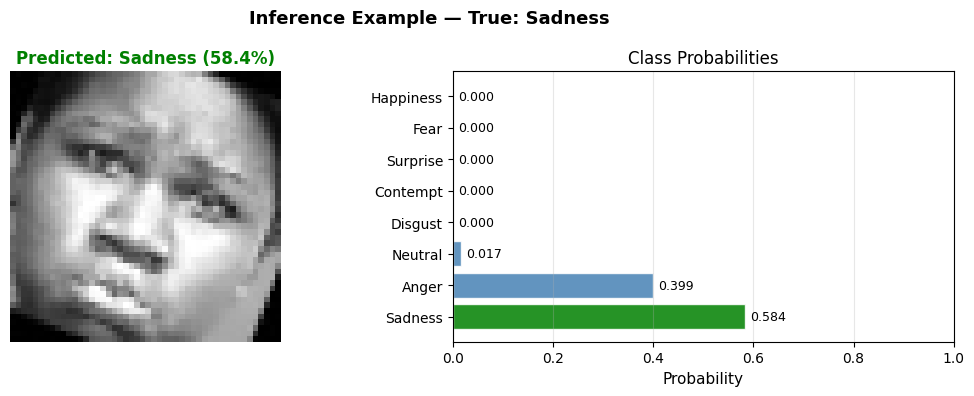

True label : Sadness
Predicted  : Sadness (confidence: 58.39%)
Result     : ✅ CORRECT


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# QUICK INFERENCE — predict emotion for one image
# ─────────────────────────────────────────────────────────────────────────────

def predict_emotion(img_path, model, idx_to_class, img_size=48, device=DEVICE):
    """Load an image, preprocess it, and return the predicted emotion."""
    image = Image.open(img_path).convert('RGB')
    image_tensor = val_test_transforms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(image_tensor), dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probabilities))
    predicted_class = idx_to_class[pred_idx]
    confidence = float(probabilities[pred_idx])
    all_probs = {idx_to_class[i]: float(probabilities[i]) for i in range(len(probabilities))}
    return predicted_class, confidence, all_probs


sample_path, sample_label_idx = random.choice(test_dataset.samples)
sample_emotion = idx_to_class[sample_label_idx]
pred_class, confidence, all_probs = predict_emotion(sample_path, model, idx_to_class)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'Inference Example — True: {sample_emotion}', fontsize=13, fontweight='bold')

img_display = Image.open(sample_path).convert('RGB')
axes[0].imshow(img_display)
color = 'green' if pred_class == sample_emotion else 'red'
axes[0].set_title(f'Predicted: {pred_class} ({confidence * 100:.1f}%)', color=color, fontsize=12, fontweight='bold')
axes[0].axis('off')

sorted_probs = dict(sorted(all_probs.items(), key=lambda item: item[1], reverse=True))
bar_colors = ['green' if class_name == sample_emotion else ('steelblue' if class_name != pred_class else 'tomato') for class_name in sorted_probs.keys()]
axes[1].barh(list(sorted_probs.keys()), list(sorted_probs.values()), color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probability', fontsize=11)
axes[1].set_title('Class Probabilities', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, (class_name, probability) in enumerate(sorted_probs.items()):
    axes[1].text(probability + 0.01, i, f'{probability:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'True label : {sample_emotion}')
print(f'Predicted  : {pred_class} (confidence: {confidence * 100:.2f}%)')
correct = '✅ CORRECT' if pred_class == sample_emotion else '❌ INCORRECT'
print(f'Result     : {correct}')